In [3]:
import fmatoolbox as fma
from math import *
import matplotlib.pyplot as plt
import numpy as np
import regions as rg
from scipy import signal
from scipy.stats import spearmanr
%load_ext autoreload
%autoreload 2

In [4]:
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'

In [5]:
R = rg.data.Regions(session,states=['sws','rem'],events=['ripples'])

In [ ]:
size, intervals, size_t, profiles = R.avalanches(regs=None,states="sws",thresh=0,window=0.05,step=1,smooth=None, profile=True)

Préparation des arrays de corrélation

In [7]:
def centered_size(size, profiles):
   # print(len(size),len(profiles))
    S=[0 for i in range(len(profiles))]
    indp=0
    inds=0
    while indp < len(profiles):
        if profiles[indp]==0:
            indp+=1
        else:
            inddeb = indp
            while indp< len(profiles) and profiles[indp]!=0:
                indp+=1
            indS= (indp+inddeb)//2
            S[indS] = size[inds]
            inds+=1
    return S

In [8]:
#Test
s,p =[10, 30, 20],[2,3,4,5,4,3,0,1,5,63,3,1,0,0,0,4,4,5,3,3,0]
centered_size(s,p)

[0, 0, 0, 10, 0, 0, 0, 0, 0, 30, 0, 0, 0, 0, 0, 0, 0, 20, 0, 0, 0]

In [9]:
Snr = centered_size(size["nr"], profiles["nr"])
Spfc = centered_size(size["pfc"], profiles["pfc"])
Shpc = centered_size(size["hpc"], profiles["hpc"])

Pnr = profiles["nr"]
Ppfc = profiles["pfc"]
Phpc = profiles["hpc"]

In [10]:
len(Snr), len(Spfc), len(Shpc), max(Snr), len(size["nr"])

(193610, 193610, 193610, np.float64(4255.999999996129), 22134)

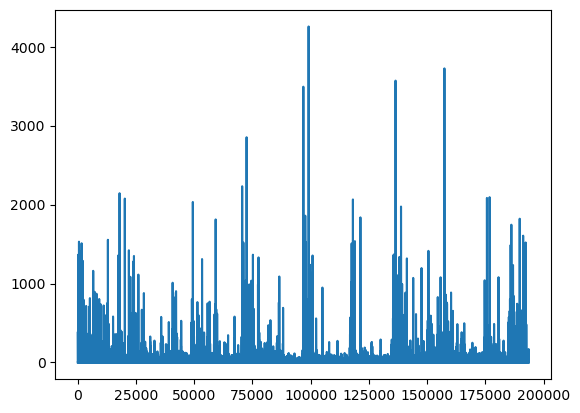

In [11]:
plt.plot(Snr)
plt.show()

Corrélation

Pearson

In [12]:
def plotCorr(ax, S1, S2, taumax, threshold = 0.005,label1='S1', label2='S2', title='Cross-corrélation', bin_size=0.05, log=False):
    # calcul de la cross-corrélation normalisée
    s1 = np.array(S1)
    s2 = np.array(S2)

    # normalisation
    s1 = (s1 - np.mean(s1)) / (np.std(s1) * len(s1))
    s2 = (s2 - np.mean(s2)) / np.std(s2)

    corr = signal.correlate(s1, s2, mode='full')
    taus = signal.correlation_lags(len(s1), len(s2), mode='full')*bin_size

    # restreindre à [-taumax, taumax]
    tau_mask = (taus >= -taumax) & (taus <= taumax)
    taus = taus[tau_mask]
    corr = corr[tau_mask]

    ax.plot(taus, corr)

    mask = corr > threshold
   # ax.plot(taus[mask], corr[mask], 'r-')
    ax.axhline(threshold, color='r', linestyle='--', linewidth=0.8)

    ax.set_xlabel('τ')
    ax.set_ylabel('Corr(' + label1 + ', ' + label2 + '(·+τ))')
    ax.set_title(title)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)

    if log:
        ax.set_yscale('log')

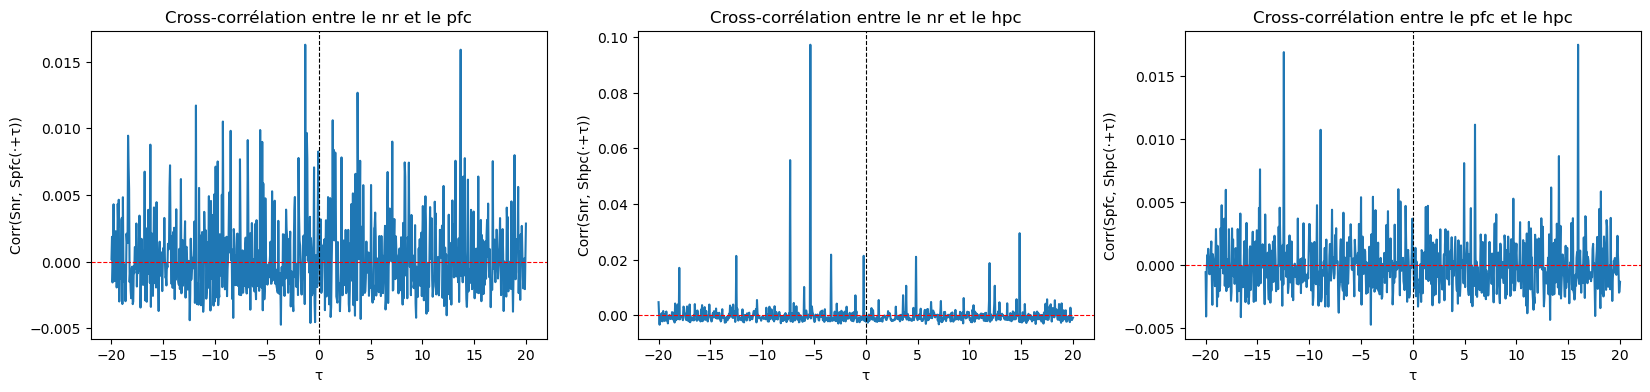

In [13]:
# Sizes centrées

fig, axs = plt.subplots(1, 3, figsize=(20, 4))
ax1, ax2, ax3= axs.flatten()
tm=20
threshold = 0

plotCorr(ax1,Snr, Spfc, tm, threshold, "Snr", "Spfc", "Cross-corrélation entre le nr et le pfc")
plotCorr(ax2,Snr, Shpc, tm, threshold, "Snr", "Shpc", "Cross-corrélation entre le nr et le hpc")
plotCorr(ax3,Spfc, Shpc, tm, threshold, "Spfc", "Shpc", "Cross-corrélation entre le pfc et le hpc")

#plotCorr(ax4,Snr, Snr, tm, threshold, "Snr", "Snr", "Auto-corrélation du nr", True)
#plotCorr(ax5,Spfc, Spfc, tm, threshold, "Spfc", "Spfc", "Auto-corrélation du pfc", True)
#plotCorr(ax6,Shpc, Shpc, tm, threshold, "Shpc", "Shpc", "Auto-corrélation du hpc", True)

plt.show()

Spearman

In [14]:
def SpearmanCorr(S1, S2, taumax=None, zone=None):
    s1 = np.array(S1)
    s2 = np.array(S2)
    
    if zone is not None:#zone est un intervalle d'indices, pas de temps 
        s1=s1[zone[0]:zone[1]]
        s2=s2[zone[0]:zone[1]]

    stat = []
    pv = []
    lags = range(max(-(len(s2)-1), -taumax), min(len(s1)-1, taumax)+1)
    
    for i in lags:
        if i >= 0:
            a = s1[i:]
            b = s2[:len(s2)-i] if i > 0 else s2
        else:
            a = s1[:len(s1)+i]
            b = s2[-i:]
        res = spearmanr(a, b)
        stat.append(res.statistic)
        pv.append(res.pvalue)
    
    return np.array(stat), np.array(pv), np.array(list(lags))

In [15]:

def plotSpearmanCorr(ax1, ax2, S1, S2, stat, pv,lags,taumax, threshold = 0.005, bin_size=0.05, label1='S1', label2='S2', title='Spearman Correlation', log=False):
    if stat is None or pv is None:
        stat, pv, lags = SpearmanCorr(S1, S2, taumax)

    stat = np.array(stat)
    pv   = np.array(pv)
    taus = np.array(lags)#np.arange(max(-taumax,int(lags[0])), min(taumax+1, int(lags[-1])+1))
    taus=taus*bin_size
    #print(taus)

    ax1.plot(taus, stat, 'b-', label='Spearman r')
    ax2.plot(taus, pv,   'g-', label='p-value')
    
   # mask = stat > threshold
    #ax1.plot(taus[mask], stat[mask], 'r-')
   # ax1.axhline(threshold, color='r', linestyle='--', linewidth=0.8)

    ax1.set_xlabel('τ')
    ax1.set_ylabel('SpearmanCorr(' + label1 + ', ' + label2 + '(·+τ))')
    ax2.set_xlabel('τ')
    ax2.set_ylabel('p-value')
    ax1.set_title(title)
    ax1.axvline(0, color='k', linestyle='--', linewidth=0.8)

    if log:
        ax1.set_yscale('log')

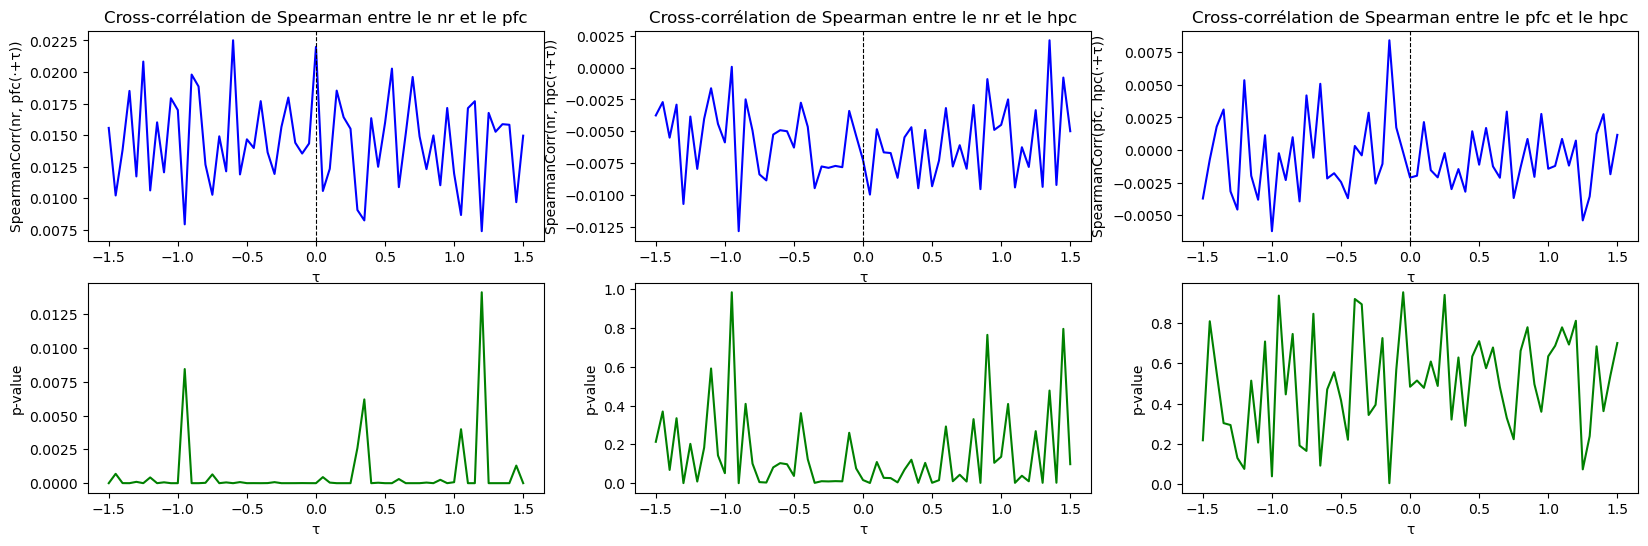

In [16]:
#Sizes centrées

fig, axs = plt.subplots(2, 3, figsize=(20, 6))
#ax1, ax2, ax3= axs.flatten()

tm = 30
rgs = ['nr', 'pfc', 'hpc']
for i in range(len(rgs)-1):
    for j in range(i+1, len(rgs)):
        ax1 = axs.flatten()[i+j-1]
        ax2 = axs.flatten()[i+j+2]
        S1 = centered_size(size[rgs[i]], profiles[rgs[i]])
        S2 = centered_size(size[rgs[j]], profiles[rgs[j]])
        stat, pv, lags = SpearmanCorr(S1, S2, tm, zone=[0,110000])
        plotSpearmanCorr(ax1, ax2 ,S1, S2, stat, pv, lags, tm, threshold, 0.05,rgs[i], rgs[j], f"Cross-corrélation de Spearman entre le {rgs[i]} et le {rgs[j]}")
plt.show()

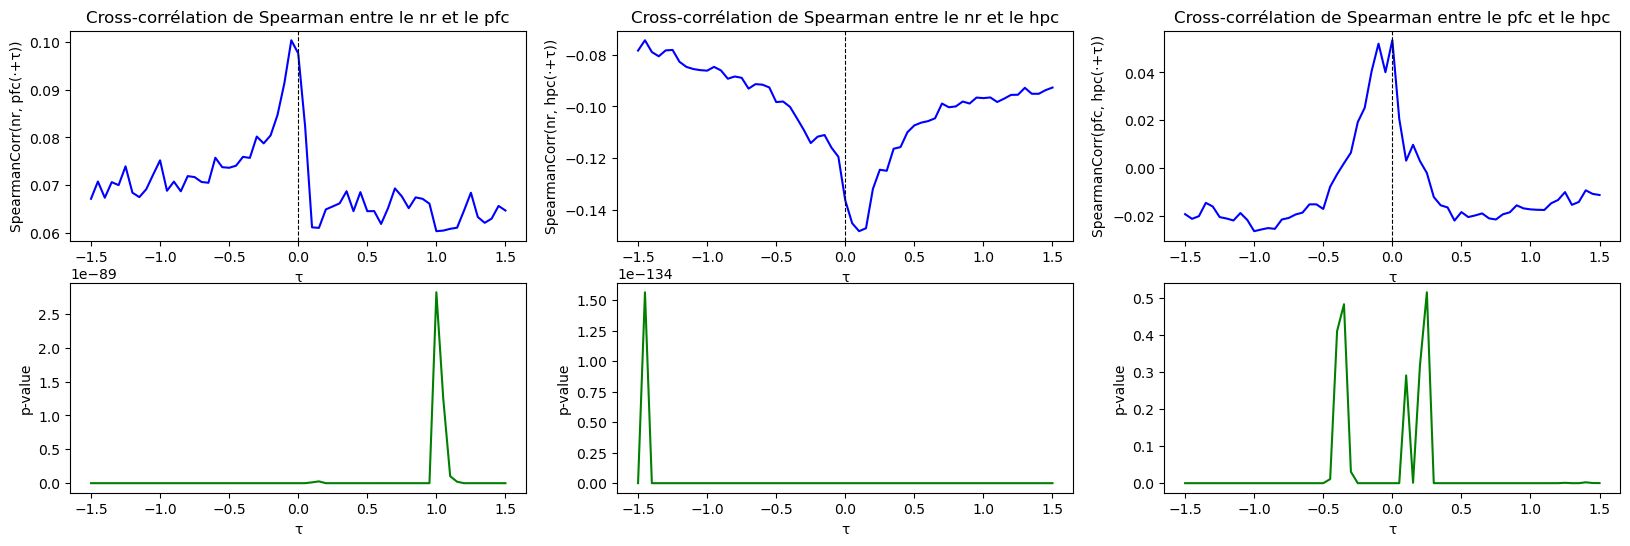

In [ ]:
# Profiles

fig, axs = plt.subplots(2, 3, figsize=(20, 6))
threshold=0
tm = 30
rgs = ['nr', 'pfc', 'hpc']
for i in range(len(rgs)-1):
    for j in range(i+1, len(rgs)):
        ax1 = axs.flatten()[i+j-1]
        ax2 = axs.flatten()[i+j+2]
        S1 = profiles[rgs[i]]
        S2 = profiles[rgs[j]] 
        stat, pv, lags = SpearmanCorr(S1, S2, tm, zone=[0,110000])
        plotSpearmanCorr(ax1, ax2 ,S1, S2, stat, pv, lags, tm, threshold, 0.05,rgs[i], rgs[j], f"Cross-corrélation de Spearman entre le {rgs[i]} et le {rgs[j]}")
plt.show()

In [27]:
# Tau pertinent pour chaque couple de région
tm = 30
bs=0.005
size, intervals, size_t, profiles = R.avalanches(regs=None,states="sws",thresh=0,window=bs,step=1,smooth=None, profile=True)
rgs = ['nr', 'pfc', 'hpc']
for i in range(len(rgs)-1):
    for j in range(i+1, len(rgs)):
        ax1 = axs.flatten()[i+j-1]
        ax2 = axs.flatten()[i+j+2]
        S1 = profiles[rgs[i]]
        S2 = profiles[rgs[j]] 
        stat, pv, lags = SpearmanCorr(S1, S2, tm, zone=[0,110000])
       #Corrélation maximale
        idx_max = np.argmax(stat)
        rho_max = stat[idx_max]
        tau_max = lags[idx_max]*bs
        pval_max = pv[idx_max]
       #Corrélation maximale en valeur absolue
        idx_max_abs = np.argmax(np.abs(stat))
        rho_max_abs = stat[idx_max_abs]
        tau_max_abs = lags[idx_max_abs]*bs
        pval_max_abs = pv[idx_max_abs]
        # Prints
        print(f"Entre les régions {rgs[i]} et {rgs[j]} :")
        print(f"  - Corrélation maximale : rho = {rho_max:.3f}, tau = {tau_max:.3f}, p-value = {pval_max:.3e}")
        print(f"  - Corrélation max (|rho|) : rho = {rho_max_abs:.3f}, tau = {tau_max_abs:.3f}, p-value = {pval_max_abs:.3e}")

        if i==1 and j==2:
            stat_copy = stat.copy()
            stat_copy[idx_max] = -np.inf  # on exclut le max
            idx_max2 = np.argmax(stat_copy)
            rho_max2 = stat[idx_max2]
            tau_max2 = lags[idx_max2]*bs
            pval_max2 = pv[idx_max2]
            print(f"  - Corrélation seconde maximale : rho = {rho_max2:.3f}, tau = {tau_max2:.3f}, p-value = {pval_max2:.3e}")
        print("")

Entre les régions nr et pfc :
  - Corrélation maximale : rho = 0.028, tau = -0.070, p-value = 1.765e-20
  - Corrélation max (|rho|) : rho = 0.028, tau = -0.070, p-value = 1.765e-20

Entre les régions nr et hpc :
  - Corrélation maximale : rho = -0.063, tau = -0.150, p-value = 6.351e-96
  - Corrélation max (|rho|) : rho = -0.092, tau = 0.075, p-value = 5.139e-204

Entre les régions pfc et hpc :
  - Corrélation maximale : rho = 0.015, tau = 0.000, p-value = 3.080e-07
  - Corrélation max (|rho|) : rho = 0.015, tau = 0.000, p-value = 3.080e-07
  - Corrélation seconde maximale : rho = 0.015, tau = 0.010, p-value = 1.152e-06



Chevauchement des intervals et profiles

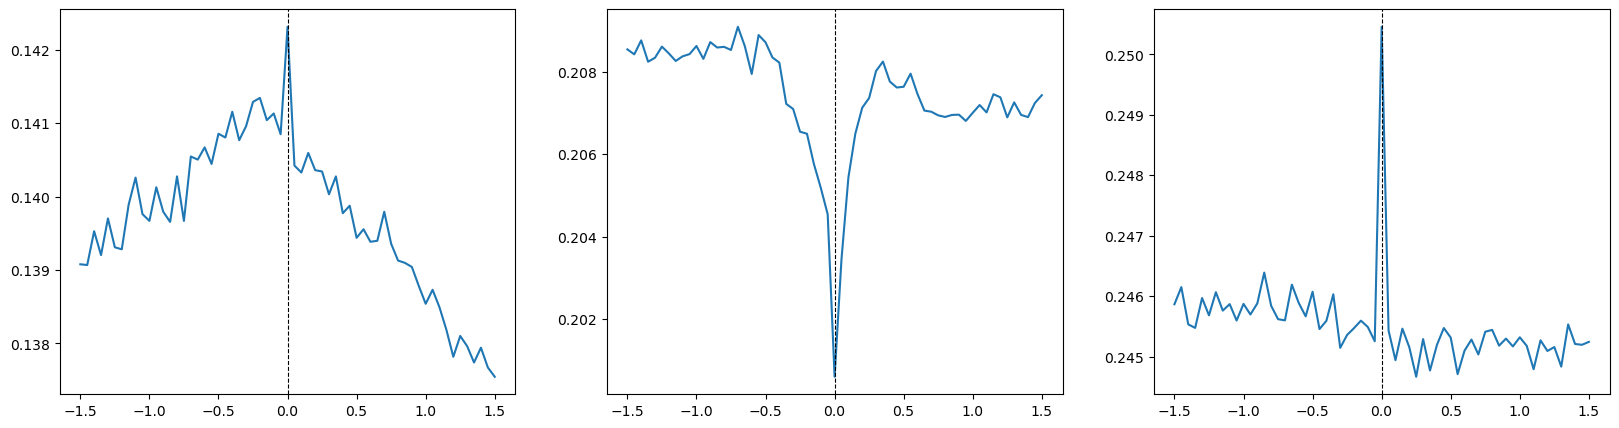

In [29]:
# Intervalles

tm = 30
rgs = ['nr', 'pfc', 'hpc']
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
n=0
binsize=0.05
for i in range(len(rgs)-1):
    for j in range(i+1, len(rgs)):
        ax = axs.flatten()[n]
        chev=[]
        time=[]  
        S1 = np.array(intervals[rgs[i]])
        S2 = np.array(intervals[rgs[j]])
        m1 = max(S1[:,1])
        m2 = max(S2[:,1])
        deb = min([S1[:,0].min(), S2[:,0].min()])
        for t in range(-tm, tm+1):
            if t >= 0:
                tot = min(m1-t, m2)
            else:
                tot = min(m2+t, m1)
            a = np.array(S1)
            b = np.array(S2)+t
            #chevauchement = overlap_opti(a,b)
            intersection = np.array(fma.general.intersectIntervals((a,b)))
            chevauchement = (intersection[:,1]-intersection[:,0]).sum()
            time.append(t*binsize)
            chev.append(chevauchement / tot)
        ax.plot(time, chev)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        n+=1
plt.show()

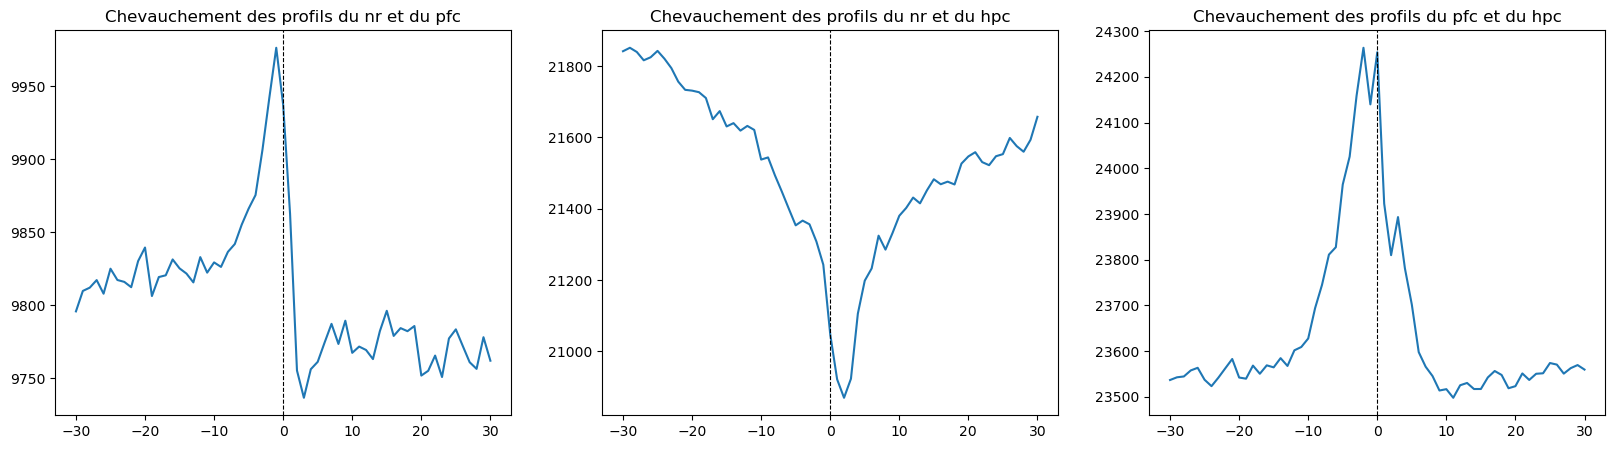

In [20]:
# Profiles

tm = 30
rgs = ['nr', 'pfc', 'hpc']
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
n=0
for i in range(len(rgs)-1):
    for j in range(i+1, len(rgs)):
        ax = axs.flatten()[n]
        chev=[]
        time=[]  
        S1 = np.array(profiles[rgs[i]])
        S2 = np.array(profiles[rgs[j]])
        m = len(S1)
        for t in range(-tm, tm+1):
            if t >= 0:
                tot = m-t
                a = np.array(S1[t:])
                b = np.array(S2[:m-t])
            else:
                tot = m+t
                a = np.array(S1[:m+t])
                b = np.array(S2[-t:])
            #chevauchement = overlap_opti(a,b)
            chevauchement = np.dot(a, b)
            time.append(t)
            chev.append(chevauchement / tot)
        ax.plot(time, chev)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.set_title(f"Chevauchement des profils du {rgs[i]} et du {rgs[j]}")
        n+=1
plt.show()

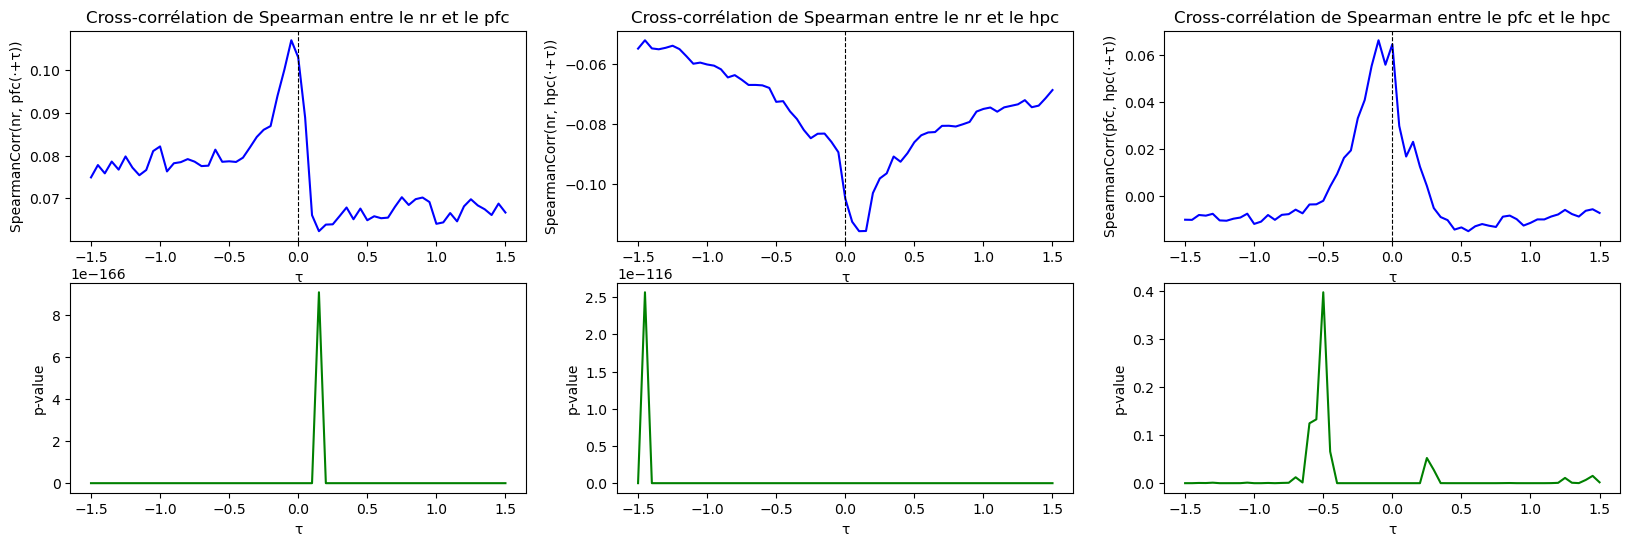

In [21]:
# Analogie à une spearman corr de profiles sur toute la session

fig, axs = plt.subplots(2, 3, figsize=(20, 6))
threshold=0
tm = 30
rgs = ['nr', 'pfc', 'hpc']
for i in range(len(rgs)-1):
    for j in range(i+1, len(rgs)):
        ax1 = axs.flatten()[i+j-1]
        ax2 = axs.flatten()[i+j+2]
        S1 = profiles[rgs[i]]
        S2 = profiles[rgs[j]] 
        stat, pv, lags = SpearmanCorr(S1, S2, tm) #J'ai enlevé zones 
        plotSpearmanCorr(ax1, ax2 ,S1, S2, stat, pv, lags, tm, threshold, 0.05,rgs[i], rgs[j], f"Cross-corrélation de Spearman entre le {rgs[i]} et le {rgs[j]}")
plt.show()